# Notebook 02 - Pr?traitement

Nous avons besoin de rendre les images plus stables avant Lucas-Kanade. Cette ?tape permet de produire des images en niveaux de gris avec un contraste local am?lior? et moins de bruit.

In [7]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "car" / "car-11"
IMG_DIR = DATA_DIR / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
FRAMES_DIR = RESULTS_DIR / "frames_output"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

print("Racine du projet:", PROJECT_ROOT)

import cv2
import matplotlib.pyplot as plt

from src.preprocessing import load_image, load_image_sequence, to_gray, apply_clahe, apply_blur, preprocess_image

Racine du projet: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project


## Chargement d'une frame

Nous chargeons une image repr?sentative de la sequence.

In [8]:
image_paths = load_image_sequence(IMG_DIR)
frame = load_image(image_paths[0])
print("Frame chargee:", image_paths[0].name, frame.shape)

Frame chargee: 00000001.jpg (720, 1280, 3)


## Conversion en niveaux de gris

Nous avons converti l'image en niveaux de gris car Lucas-Kanade travaille sur les variations d'intensite.

In [9]:
gray = to_gray(frame)

## CLAHE

CLAHE permet d'am?liorer le contraste local. Le parametre `clipLimit=2.0` limite l'amplification du bruit, et `tileGridSize=(8,8)` applique l'am?lioration localement sur des petites regions.

In [10]:
clahe = apply_clahe(gray, clipLimit=2.0, tileGridSize=(8, 8))

## GaussianBlur

GaussianBlur permet de r?duire le bruit. Le noyau `(5,5)` est un compromis simple : il lisse l'image sans trop effacer les contours utiles.

In [11]:
blur = apply_blur(clahe, kernel_size=(5, 5))
preprocessed = preprocess_image(frame)

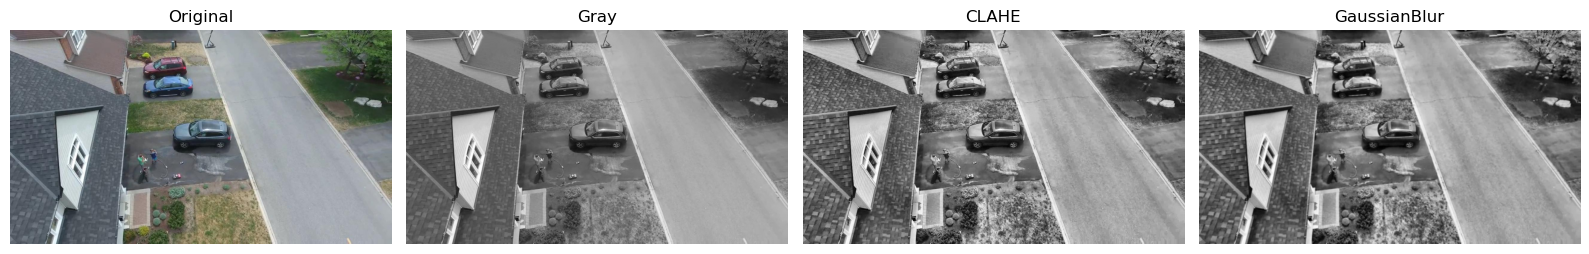

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original")
axes[1].imshow(gray, cmap="gray"); axes[1].set_title("Gray")
axes[2].imshow(clahe, cmap="gray"); axes[2].set_title("CLAHE")
axes[3].imshow(blur, cmap="gray"); axes[3].set_title("GaussianBlur")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

Nous observons que le contraste de la voiture et de ses contours devient plus exploitable. Ces ?tapes rendent les points caract?ristiques plus stables pour Lucas-Kanade.